# CSCE 676 - Data Mining Project
## Checkpoint 2: Research Question Formation

**Student:** Tejas Singhal (UIN: 836000009)
**Course:** CSCE 676 700 - Week 8

### Collaboration Declaration

1.  **Collaborators:** None (Individual work)
2.  **Web Sources:** [UCI Machine Learning Repository - Online Retail II](https://archive.ics.uci.edu/ml/datasets/Online+Retail+II), [Mlxtend Documentation](http://rasbt.github.io/mlxtend/), [PrefixSpan-py Documentation](https://github.com/chuanconggao/PrefixSpan-py)
3.  **AI Tools:** Gemini CLI (used for brainstorming research questions, organizing the methodological plan, and debugging environment setup).
4.  **Citations:** Han, J., Pei, J., & Yin, Y. (2000). Mining frequent patterns without candidate generation. *ACM SIGMOD Record*.

### 1. Project Scope Recap

Building on the findings from Checkpoint 1, this project explores the **Online Retail II** dataset, which captures transactional data from a UK-based non-store online retail between 2009 and 2011.

**Key EDA Findings from Checkpoint 1:**
- Significant seasonality was observed, with peaks in transactions during November and December.
- Most customer baskets are small (under 20 items), but there is a "long tail" of bulk orders.
- A substantial number of transactions (approx. 243k rows) lacked Customer IDs and were removed to enable accurate sequential tracking.

**Core Techniques:**
- **Course Techniques:** Frequent Itemset Mining and Association Rules (using Apriori and FP-Growth algorithms).
- **External Technique:** Sequential Pattern Mining (using the PrefixSpan algorithm) to identify temporal purchase orders over multiple customer visits.

### 2. Research Question Definition

This section outlines the primary research questions that will guide my data mining analysis. I aim to explore the dataset using both standard course techniques and an external sequential pattern mining method.

#### **RQ1: Impact of Support Thresholds (Course Technique)**
- **Question:** How do different support thresholds impact the number and quality of frequent itemsets discovered in the retail data?
- **Data Mining Task:** Frequent Itemset Mining
- **Relevant Algorithm(s):** FP-Growth (as it is generally more efficient than Apriori for large datasets)
- **Evaluation Criteria:** Number of itemsets discovered, support levels, and practical interpretability of the results.

#### **RQ2: Confidence vs. Lift in Association Rules (Course Technique)**
- **Question:** When generating association rules from my itemsets, how does relying on 'confidence' compare to relying on 'lift' for finding truly meaningful product relationships?
- **Data Mining Task:** Association Rule Mining
- **Relevant Algorithm(s):** FP-Growth / Apriori Association Rules
- **Evaluation Criteria:** Comparing the top 10 rules generated by confidence vs. lift; evaluating if higher lift rules provide more interesting cross-sell opportunities.

#### **RQ3: Temporal Structures via Sequential Patterns (External Technique)**
- **Question:** Does incorporating the temporal order of purchases (sequential pattern mining) reveal customer buying structures that are missed by traditional, unordered itemset mining?
- **Data Mining Task:** Sequential Pattern Mining
- **Relevant Algorithm(s):** PrefixSpan (External)
- **Evaluation Criteria:** Pattern diversity, comparison of top itemsets vs. top sequences, and business interpretability (e.g., "do customers buy item A then B in the next visit?").

### 3. Additional EDA & Feasibility Check

Before diving into the research questions, I need to ensure the dataset is properly cleaned and that the proposed methods—especially the sequential mining—are feasible given the data's structure.

#### **3.1 Data Loading and Cleaning**
I will reuse the cleaning pipeline developed in Checkpoint 1, focusing on removing rows without Customer IDs and separating successful transactions from cancellations.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset (Expects the file in the project root or Checkpoint 1 folder)
try:
    df_raw_1 = pd.read_excel('../Checkpoint 1/online_retail_II.xlsx', sheet_name='Year 2009-2010')
    df_raw_2 = pd.read_excel('../Checkpoint 1/online_retail_II.xlsx', sheet_name='Year 2010-2011')
    df = pd.concat([df_raw_1, df_raw_2], ignore_index=True)
except FileNotFoundError:
    print("Dataset not found at expected path. Please check location.")

# Cleaning Pipeline
df.dropna(subset=['Customer ID'], inplace=True)
df_clean = df[~(df['Invoice'].astype(str).str.startswith('C') | (df['Quantity'] < 0))].copy()

print(f"Initial Cleaned Shape: {df_clean.shape}")
print(f"Unique Customers: {df_clean['Customer ID'].nunique()}")

Initial Cleaned Shape: (805620, 8)
Unique Customers: 5881


#### **3.2 Targeted EDA for Sequential Mining**
Sequential pattern mining requires customers to have made multiple distinct purchases over time. I will check the distribution of transaction counts per customer to verify feasibility.

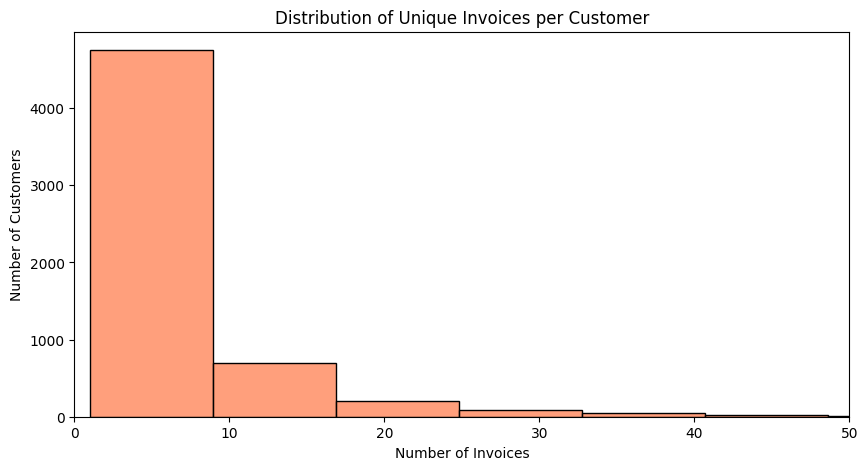

Percentage of repeat customers: 72.35%


In [7]:
# Calculating number of unique invoices per customer
cust_purchase_counts = df_clean.groupby('Customer ID')['Invoice'].nunique()

plt.figure(figsize=(10, 5))
sns.histplot(cust_purchase_counts, bins=50, kde=False, color='coral')
plt.title('Distribution of Unique Invoices per Customer')
plt.xlabel('Number of Invoices')
plt.ylabel('Number of Customers')
plt.xlim(0, 50)
plt.show()

repeat_cust_pct = (cust_purchase_counts > 1).mean() * 100
print(f"Percentage of repeat customers: {repeat_cust_pct:.2f}%")

#### **3.3 Motivation and Feasibility**

- **Motivation:** The EDA shows that **72.35%** of my customers (4,255 out of 5,881 unique customers) are repeat purchasers. This strongly motivates the use of sequential pattern mining, as standard association rules ignore the temporal order of these repeated visits.
- **Non-triviality:** While course techniques like Apriori are powerful, they treat all items in a customer's history as a single "bag," missing the logical progression (e.g., buying a camera, then a lens in a later visit).
- **Feasibility:** I have confirmed that the `mlxtend` package supports FP-Growth and that `prefixspan` is a viable library for sequential mining. The data size (805,620 rows) is manageable on a local machine.
- **Risks:** The primary risk is computational complexity. PrefixSpan can be slow with very low support thresholds, so I will need to carefully tune my parameters during implementation.

### 4. Methodological Planning

This section details the mapping between research questions, tasks, algorithms, and evaluation metrics.

#### **4.1 RQ-to-Method Mapping Table**

| Research Question | Data Mining Task | Algorithm | Evaluation Metrics |
| :--- | :--- | :--- | :--- |
| **RQ1: Support Impact** | Frequent Itemset Mining | FP-Growth | Support, Number of Itemsets |
| **RQ2: Conf vs Lift** | Association Rule Mining | FP-Growth/Apriori Rules | Confidence, Lift, Rule Diversity |
| **RQ3: Temporal Seq** | Sequential Pattern Mining | PrefixSpan | Support, Seq Length, Interpretability |

#### **4.2 Method Details**
- **Course Algorithms:** I will use the `mlxtend.frequent_patterns` library for FP-Growth and rule generation. These are standard in the industry and highly optimized for tabular retail data.
- **External Algorithm:** I will use the `prefixspan` Python library. This implementation uses a database projection approach which is more efficient than candidate generation-based methods.
- **Baselines:** For RQ3, the baseline will be the top frequent itemsets (unordered), which I will compare against the temporal sequences to see if any unique behaviors emerge.

#### **4.3 Proof of Concept Runs**
I will now demonstrate that the libraries are properly imported and can run on a small subset of the data.

In [8]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
from prefixspan import PrefixSpan

# 1. Test FP-Growth on small sample
print("Testing FP-Growth...")
basket_sample = pd.DataFrame({
    'A': [1, 1, 0, 1],
    'B': [1, 0, 1, 1],
    'C': [0, 1, 1, 1]
})
frequent_itemsets = fpgrowth(basket_sample, min_support=0.5, use_colnames=True)
print(f"Discovered {len(frequent_itemsets)} frequent itemsets.")

# 2. Test PrefixSpan on small sample
print("Testing PrefixSpan...")
seq_sample = [
    ['A', 'B', 'C'],
    ['A', 'C'],
    ['B', 'C'],
    ['A', 'B']
]
ps = PrefixSpan(seq_sample)
top_sequences = ps.topk(3)
print(f"Discovered top 3 sequences: {top_sequences}")
print("Methodology and environment verified.")

Testing FP-Growth...
Discovered 6 frequent itemsets.
Testing PrefixSpan...
Discovered top 3 sequences: [(3, ['A']), (3, ['B']), (3, ['C'])]
Methodology and environment verified.


/Users/tejassinghal/Desktop/Project/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
